# Notebook for the 1000 Runs Ensemble

In [1]:
import pandas as pd
import os
from utils.eda_utils import EDAUtils
import boto3
import numpy as np

import re
from io import BytesIO
from urllib.parse import urlparse
from typing import List, Optional, Tuple

from botocore.config import Config
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
from functools import partial


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")
CONFIG_DIR_PATH = os.path.join(ROOT_DIR_PATH, "config")

In [4]:
os.makedirs(SSP_DIR_PATH, exist_ok=True)

In [5]:
edau = EDAUtils()

## Pull data from AWS S3


In [6]:
aws_config = edau.read_yaml(os.path.join(CONFIG_DIR_PATH, "aws_credentials_config.yaml"))
profile_name = aws_config["profile_name"]
bucket_name = aws_config["bucket_name"]
# Set your profile
session = boto3.Session(profile_name=profile_name)

# Create an S3 client or resource
s3 = session.resource('s3')

run_id = "sisepuede_run_2025-10-07t13;30;14.193421"

# Define folder prefix
prefix = f'transfers/{run_id}/'  # this is like the "folder" in S3

In [7]:
# Local destination
destination = os.path.join(SSP_DIR_PATH, run_id)
if os.path.exists(destination) and os.listdir(destination):
    print(f"Destination '{destination}' already exists and is not empty. Skipping download.")
else:
    os.makedirs(destination, exist_ok=True)
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=prefix):
        if obj.key.endswith('/') or "transformations" in obj.key:  # skip directories and transformations
            continue
        target_path = os.path.join(destination, os.path.basename(obj.key))
        print(f"Downloading {obj.key} to {target_path}")
        bucket.download_file(obj.key, target_path)

Destination '/Users/tony/Documents/sisepuede_modeling/ssp_louisiana/metamodel/data/ssp/sisepuede_run_2025-10-07t13;30;14.193421' already exists and is not empty. Skipping download.


In [8]:
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, run_id)
print(SIMULATION_DIR_PATH)

/Users/tony/Documents/sisepuede_modeling/ssp_louisiana/metamodel/data/ssp/sisepuede_run_2025-10-07t13;30;14.193421


In [9]:
SIM_PARQUET_DIR_PATH = os.path.join(SIMULATION_DIR_PATH, "parquets")

In [ ]:
# Load a single parquet file
decomposed_df = pd.read_parquet(os.path.join(SIM_PARQUET_DIR_PATH, "decomposed_combined.parquet"))
cb_df = pd.read_parquet(os.path.join(SIM_PARQUET_DIR_PATH, "combined_cb_outputs.parquet"))
lsu_data = pd.read_parquet(os.path.join(SIM_PARQUET_DIR_PATH, "combined_jobs_outputs.parquet"))

## Load and Process LHC Samples Dataframes

In [12]:
# Load lhc samples dfs
lhs_exogenous_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES.csv"))
lhs_levers_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_LHC_SAMPLES_LEVER_EFFECTS.csv"))

In [13]:
# Check design ids
lhs_exogenous_df.head()

,region,design_id,future_id,46,47,48,49,50,51,52,53,54,55,56,57,58,59
0,louisiana,-1,1,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,0.362738,0.958638,0.609931,0.110602,0.228879,0.023251,0.519864
1,louisiana,-1,2,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,0.486941,0.799062,0.646620,0.890292,0.243776,0.881897,0.307468
2,louisiana,-1,3,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,0.892889,0.603465,0.197423,0.228748,0.148648,0.914823,0.078667
3,louisiana,-1,4,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,0.084494,0.215486,0.268124,0.114697,0.215141,0.400283,0.013558
4,louisiana,-1,5,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,0.504623,0.661824,0.418552,0.042683,0.369231,0.453588,0.800351


In [14]:
lhs_exogenous_df.design_id.unique()

array([-1,  4])

In [15]:
lhs_exogenous_df[lhs_exogenous_df['design_id']== 0]

,region,design_id,future_id,46,47,48,49,50,51,52,53,54,55,56,57,58,59


In [16]:
lhs_levers_df.head()

,region,design_id,future_id,1,2,3,4,5,6,7,...,1761,1762,1767,1768,1770,1778,1780,1792,1793,1801
0,louisiana,-1,1,0.803011,0.496343,0.168613,0.203382,0.687640,0.651471,0.167822,...,0.814377,0.142605,0.097383,0.613217,0.746290,0.004296,0.883196,0.430823,0.480203,0.542153
1,louisiana,-1,2,0.186768,0.161360,0.715659,0.520522,0.244624,0.432519,0.662078,...,0.945452,0.596037,0.761325,0.972692,0.957930,0.178317,0.059578,0.241647,0.867341,0.299005
2,louisiana,-1,3,0.284609,0.129326,0.362011,0.434426,0.422840,0.683687,0.141129,...,0.564013,0.843588,0.468507,0.615248,0.581179,0.297995,0.777503,0.309742,0.127848,0.024428
3,louisiana,-1,4,0.646471,0.046774,0.689050,0.070367,0.259922,0.168926,0.246849,...,0.521076,0.511969,0.006134,0.423707,0.044680,0.753944,0.089066,0.978027,0.193832,0.578752
4,louisiana,-1,5,0.833488,0.072018,0.845239,0.160506,0.398369,0.125452,0.115764,...,0.886965,0.814298,0.761830,0.453373,0.499034,0.864098,0.349058,0.324254,0.655437,0.735588


In [17]:
lhs_levers_df.design_id.unique()

array([-1,  4])

In [18]:
# print shapes
print(lhs_exogenous_df.shape)
print(lhs_levers_df.shape)

(200000, 17)
(200000, 68)


In [ ]:
lhs_df_merged = pd.merge(lhs_exogenous_df, lhs_levers_df, on=["region", "design_id", "future_id"], how="inner", suffixes=('_X', '_L'))
lhs_df_merged.head()

,region,design_id,future_id,46,47,48,49,50,51,52,...,1761,1762,1767,1768,1770,1778,1780,1792,1793,1801
0,louisiana,-1,1,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,...,0.814377,0.142605,0.097383,0.613217,0.746290,0.004296,0.883196,0.430823,0.480203,0.542153
1,louisiana,-1,2,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,...,0.945452,0.596037,0.761325,0.972692,0.957930,0.178317,0.059578,0.241647,0.867341,0.299005
2,louisiana,-1,3,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,...,0.564013,0.843588,0.468507,0.615248,0.581179,0.297995,0.777503,0.309742,0.127848,0.024428
3,louisiana,-1,4,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,...,0.521076,0.511969,0.006134,0.423707,0.044680,0.753944,0.089066,0.978027,0.193832,0.578752
4,louisiana,-1,5,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,...,0.886965,0.814298,0.761830,0.453373,0.499034,0.864098,0.349058,0.324254,0.655437,0.735588


In [20]:
# Filter the lhs_df_merged to only include rows where design_id is 4
lhs_df_merged = lhs_df_merged[lhs_df_merged.design_id == 4]
lhs_df_merged.shape

(100000, 82)

In [21]:
lhs_df_merged.design_id.unique()

array([4])

In [22]:
# NOTE: check col names, there should be no duplicates
lhs_df_merged.columns

Index(['region', 'design_id', 'future_id', '46', '47', '48', '49', '50', '51',
       '52', '53', '54', '55', '56', '57', '58', '59', '1', '2', '3', '4', '5',
       '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17',
       '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29',
       '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41',
       '42', '43', '44', '45', '1714', '1715', '1718', '1720', '1723', '1740',
       '1741', '1744', '1747', '1749', '1761', '1762', '1767', '1768', '1770',
       '1778', '1780', '1792', '1793', '1801'],
      dtype='object')

In [23]:
lhs_df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 100000 to 199999
Data columns (total 82 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   region     100000 non-null  object 
 1   design_id  100000 non-null  int64  
 2   future_id  100000 non-null  int64  
 3   46         100000 non-null  float64
 4   47         100000 non-null  float64
 5   48         100000 non-null  float64
 6   49         100000 non-null  float64
 7   50         100000 non-null  float64
 8   51         100000 non-null  float64
 9   52         100000 non-null  float64
 10  53         100000 non-null  float64
 11  54         100000 non-null  float64
 12  55         100000 non-null  float64
 13  56         100000 non-null  float64
 14  57         100000 non-null  float64
 15  58         100000 non-null  float64
 16  59         100000 non-null  float64
 17  1          100000 non-null  float64
 18  2          100000 non-null  float64
 19  3          100000 non-n

## Load SISEPUEDE WIDE_INPUTS_OUTPUTS

In [24]:
attr_primary_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"))
attr_primary_df

,primary_id,design_id,strategy_id,future_id
0,36800368,4,0,0
1,43800438,4,6004,0
2,43800439,4,6004,1
3,43800440,4,6004,2
4,43800441,4,6004,3
...,...,...,...,...
99997,43900434,4,6004,99996
99998,43900435,4,6004,99997
99999,43900436,4,6004,99998
100000,43900437,4,6004,99999


In [25]:
attr_primary_df = attr_primary_df[attr_primary_df["strategy_id"].isin([6004])]
attr_primary_df

,primary_id,design_id,strategy_id,future_id
1,43800438,4,6004,0
2,43800439,4,6004,1
3,43800440,4,6004,2
4,43800441,4,6004,3
5,43800442,4,6004,4
...,...,...,...,...
99997,43900434,4,6004,99996
99998,43900435,4,6004,99997
99999,43900436,4,6004,99998
100000,43900437,4,6004,99999


In [26]:
decomposed_df.head()

,primary_id,time_period,total_emissions,efficfactor_enfu_industrial_energy_fuel_biomass,efficfactor_enfu_industrial_energy_fuel_coal,efficfactor_enfu_industrial_energy_fuel_coke,efficfactor_enfu_industrial_energy_fuel_diesel,efficfactor_enfu_industrial_energy_fuel_electricity,efficfactor_enfu_industrial_energy_fuel_furnace_gas,efficfactor_enfu_industrial_energy_fuel_gasoline,...,totalvalue_enfu_fuel_consumed_inen_fuel_coke,totalvalue_enfu_fuel_consumed_inen_fuel_diesel,totalvalue_enfu_fuel_consumed_inen_fuel_electricity,totalvalue_enfu_fuel_consumed_inen_fuel_furnace_gas,totalvalue_enfu_fuel_consumed_inen_fuel_gasoline,totalvalue_enfu_fuel_consumed_inen_fuel_hydrocarbon_gas_liquids,totalvalue_enfu_fuel_consumed_inen_fuel_hydrogen,totalvalue_enfu_fuel_consumed_inen_fuel_kerosene,totalvalue_enfu_fuel_consumed_inen_fuel_natural_gas,totalvalue_enfu_fuel_consumed_inen_fuel_oil
0,43800497,7,192.501062,0.602414,0.602414,0.602414,0.753018,2.409658,0.803219,0.753018,...,0.404062,178.601128,1174.317781,5.268705e+07,181.622909,0.0,0.317356,0.0,1997.361189,276.982160
1,43800497,8,187.719262,0.604839,0.604839,0.604839,0.756048,2.419355,0.806452,0.756048,...,0.061134,182.504394,1145.385420,5.254285e+07,175.198697,0.0,0.356350,0.0,1756.982222,290.281161
2,43800497,9,189.224632,0.607273,0.607273,0.607273,0.759091,2.429091,0.809697,0.759091,...,0.022939,194.993152,1136.290977,5.163389e+07,180.826891,0.0,0.374174,0.0,1717.637258,310.608648
3,43800497,10,189.818129,0.609716,0.609716,0.609716,0.762146,2.438866,0.812955,0.762146,...,0.018743,195.487695,1113.543102,5.045960e+07,180.184554,0.0,0.402038,0.0,1748.397107,310.009898
4,43800497,11,190.762750,0.612170,0.612170,0.612170,0.765213,2.448680,0.816227,0.765213,...,0.014263,195.467729,1104.997405,4.920852e+07,177.840154,0.0,0.424731,0.0,1784.410018,304.599276


In [27]:
decomposed_df.primary_id.nunique()

99993

## Load Costs-Benefits Data

In [28]:
cb_df.head()


,primary_id,future_id,strategy_code,Year,air_pollution,technical_cost
0,43800485,47,PFLO:ALL_LA_ACTIONS,2022.0,0.000000e+00,0.000000
1,43800485,47,PFLO:ALL_LA_ACTIONS,2023.0,0.000000e+00,0.000000
2,43800485,47,PFLO:ALL_LA_ACTIONS,2024.0,0.000000e+00,0.000000
3,43800485,47,PFLO:ALL_LA_ACTIONS,2025.0,8.427320e-16,-0.004082
4,43800485,47,PFLO:ALL_LA_ACTIONS,2026.0,0.000000e+00,-0.005318


In [29]:
cb_df.primary_id.nunique()

99717

## Load LSU data

In [31]:
lsu_data.head()

,time,primary_id,la_value_direct,la_value_indirect,la_value_induced,la_earnings_direct,la_earnings_indirect,la_earnings_induced,la_employment_direct,la_employment_indirect,la_employment_total
0,6,43800487,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,7,43800487,-5.960464e-08,-2.980232e-08,-4.470348e-08,-4.470348e-08,-1.490116e-08,-2.235174e-08,-6.821210e-13,-3.410605e-13,-1.818989e-12
2,8,43800487,-2.980232e-08,-1.490116e-08,-2.980232e-08,-2.980232e-08,-7.450581e-09,-1.490116e-08,-4.547474e-13,-1.136868e-13,-4.547474e-13
3,9,43800487,-4.887581e-06,-1.490116e-06,4.678965e-06,-1.296401e-06,-9.834766e-07,2.816319e-06,-1.273293e-11,-1.330136e-11,3.319656e-11
4,10,43800487,4.735197e+03,1.342342e+03,1.993849e+03,2.465216e+03,7.587196e+02,1.057718e+03,3.248783e-02,1.127732e-02,6.704874e-02


In [32]:
lsu_data.primary_id.nunique()

97454

In [33]:
lsu_data=lsu_data.rename(columns={"la_employment_total": "num_jobs"})

In [34]:
lsu_data.head()

,time,primary_id,la_value_direct,la_value_indirect,la_value_induced,la_earnings_direct,la_earnings_indirect,la_earnings_induced,la_employment_direct,la_employment_indirect,num_jobs
0,6,43800487,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,7,43800487,-5.960464e-08,-2.980232e-08,-4.470348e-08,-4.470348e-08,-1.490116e-08,-2.235174e-08,-6.821210e-13,-3.410605e-13,-1.818989e-12
2,8,43800487,-2.980232e-08,-1.490116e-08,-2.980232e-08,-2.980232e-08,-7.450581e-09,-1.490116e-08,-4.547474e-13,-1.136868e-13,-4.547474e-13
3,9,43800487,-4.887581e-06,-1.490116e-06,4.678965e-06,-1.296401e-06,-9.834766e-07,2.816319e-06,-1.273293e-11,-1.330136e-11,3.319656e-11
4,10,43800487,4.735197e+03,1.342342e+03,1.993849e+03,2.465216e+03,7.587196e+02,1.057718e+03,3.248783e-02,1.127732e-02,6.704874e-02


In [35]:
lsu_data["num_jobs"].describe()

count    2.923620e+06
mean    -3.814764e+04
std      3.889620e+04
min     -2.284907e+05
25%     -6.391770e+04
50%     -4.320395e+04
75%     -4.185695e-02
max      1.044638e+05
Name: num_jobs, dtype: float64

In [36]:
lsu_data["earning_per_job"] = (
    lsu_data[["la_earnings_direct", "la_earnings_indirect", "la_earnings_induced"]].sum(axis=1, min_count=1)
    / lsu_data["num_jobs"].replace(0, pd.NA)
)

In [37]:
lsu_data["earning_per_job"].describe()

count     2.825033e+06
unique    2.533937e+06
top       1.724824e+04
freq      8.021000e+03
Name: earning_per_job, dtype: float64

In [38]:
lsu_data.primary_id.nunique()

97454

In [39]:
lsu_data.tail()

,time,primary_id,la_value_direct,la_value_indirect,la_value_induced,la_earnings_direct,la_earnings_indirect,la_earnings_induced,la_employment_direct,la_employment_indirect,num_jobs,earning_per_job
2923615,31,43900436,1.608216e+10,5.319495e+09,-1.873572e+10,5.811929e+09,2.933846e+09,-9.940477e+09,62940.476009,42352.256592,-113326.182499,10542.147264
2923616,32,43900436,1.589456e+10,5.223615e+09,-1.936920e+10,5.681070e+09,2.879724e+09,-1.027656e+10,61128.069679,41528.498909,-123353.827483,13909.320456
2923617,33,43900436,1.640966e+10,5.386409e+09,-1.973524e+10,5.887640e+09,2.971574e+09,-1.047077e+10,63561.347275,42863.681534,-123857.157948,13011.425596
2923618,34,43900436,1.695682e+10,5.557367e+09,-2.012683e+10,6.089340e+09,3.068688e+09,-1.067854e+10,65857.632222,44263.390801,-124734.257846,12189.975677
2923619,35,43900436,1.340812e+10,4.483880e+09,-2.228440e+10,4.230553e+09,2.462650e+09,-1.182315e+10,41406.998217,35248.629281,-183384.363058,27973.730014


## Data Cleaning

### SISEPUEDE Emission data

In [43]:
# rename total_emission to emission_total
decomposed_df = decomposed_df.rename(columns={"total_emissions": "emission_total"})
decomposed_df.head()

,primary_id,time_period,emission_total,efficfactor_enfu_industrial_energy_fuel_biomass,efficfactor_enfu_industrial_energy_fuel_coal,efficfactor_enfu_industrial_energy_fuel_coke,efficfactor_enfu_industrial_energy_fuel_diesel,efficfactor_enfu_industrial_energy_fuel_electricity,efficfactor_enfu_industrial_energy_fuel_furnace_gas,efficfactor_enfu_industrial_energy_fuel_gasoline,...,totalvalue_enfu_fuel_consumed_inen_fuel_coke,totalvalue_enfu_fuel_consumed_inen_fuel_diesel,totalvalue_enfu_fuel_consumed_inen_fuel_electricity,totalvalue_enfu_fuel_consumed_inen_fuel_furnace_gas,totalvalue_enfu_fuel_consumed_inen_fuel_gasoline,totalvalue_enfu_fuel_consumed_inen_fuel_hydrocarbon_gas_liquids,totalvalue_enfu_fuel_consumed_inen_fuel_hydrogen,totalvalue_enfu_fuel_consumed_inen_fuel_kerosene,totalvalue_enfu_fuel_consumed_inen_fuel_natural_gas,totalvalue_enfu_fuel_consumed_inen_fuel_oil
0,43800497,7,192.501062,0.602414,0.602414,0.602414,0.753018,2.409658,0.803219,0.753018,...,0.404062,178.601128,1174.317781,5.268705e+07,181.622909,0.0,0.317356,0.0,1997.361189,276.982160
1,43800497,8,187.719262,0.604839,0.604839,0.604839,0.756048,2.419355,0.806452,0.756048,...,0.061134,182.504394,1145.385420,5.254285e+07,175.198697,0.0,0.356350,0.0,1756.982222,290.281161
2,43800497,9,189.224632,0.607273,0.607273,0.607273,0.759091,2.429091,0.809697,0.759091,...,0.022939,194.993152,1136.290977,5.163389e+07,180.826891,0.0,0.374174,0.0,1717.637258,310.608648
3,43800497,10,189.818129,0.609716,0.609716,0.609716,0.762146,2.438866,0.812955,0.762146,...,0.018743,195.487695,1113.543102,5.045960e+07,180.184554,0.0,0.402038,0.0,1748.397107,310.009898
4,43800497,11,190.762750,0.612170,0.612170,0.612170,0.765213,2.448680,0.816227,0.765213,...,0.014263,195.467729,1104.997405,4.920852e+07,177.840154,0.0,0.424731,0.0,1784.410018,304.599276


### Production Data

In [44]:
# 2) Define your fuels and sectors
relevant_fuels = ['biomass', 
                    'coal', 
                    'coke', 
                    'diesel', 
                    'electricity',
                    'furnace_gas',
                    'gasoline', 
                    'hydrocarbon_gas_liquids',
                    'hydrogen',
                    'kerosene',
                    'natural_gas',
                    'natural_gas_liquid',
                    'oil']

sectors = ['agriculture_and_livestock',
           'cement',
           'chemicals',
           'electronics',
           'glass',
           'lime_and_carbonite',
           'metals',
           'mining',
           'other_product_manufacturing',
           'paper',
           'plastic',
           'recycled_glass',
           'recycled_metals',
           'recycled_paper',
           'recycled_plastic',
           'recycled_rubber_and_leather',
           'recycled_textiles',
           'recycled_wood',
           'rubber_and_leather',
           'textiles',
           'wood']

In [45]:
# 4) Industrial cost parameters
capex_industrial_electricity = 92666.6 * 21
capex_industrial_other       = 92666.6 * 12
opex_industrial_electricity  = 92666.6 * 2.5
opex_industrial_other        = 92666.6 * 4.5
capex_multiplier_efficiency = 10000000
opex_multiplier_efficiency = 0

In [46]:
# 5) Loop over fuels and sectors
# Use the original dataframe directly
# Initialize results dataframe
ind_fuel_demand_by_sector = pd.DataFrame({
    'primary_id': decomposed_df['primary_id'],
    'time_period': decomposed_df['time_period']
}, index=decomposed_df.index)

# Helper alias for tricky fuel names
alias = {
    'natural_gas_liquid': ['natural_gas_liquid', 'natural_gas_liquids'],
    'biomass': ['biomass', 'solid_biomass'],   # <-- added
}

for fuel in relevant_fuels:
    fuel_keys = alias.get(fuel, [fuel])  # use aliases everywhere for this fuel

    # ------------------------------------------------------------
    # ENTc (fuel-only) — handled OUTSIDE sector loop
    # ------------------------------------------------------------
    entc_found_col = None
    for k in fuel_keys:
        cand = f'energy_demand_enfu_subsector_total_pj_entc_fuel_{k}'
        if cand in decomposed_df.columns:
            entc_found_col = cand
            break
    if entc_found_col is not None:
        ind_fuel_demand_by_sector[entc_found_col] = decomposed_df[entc_found_col]

    # ------------------------------------------------------------
    # Efficiency column (accept any alias)
    # ------------------------------------------------------------
    eff_cols = [
        c for c in decomposed_df.columns
        if any(c.startswith(f'efficfactor_enfu_industrial_energy_fuel_{k}') for k in fuel_keys)
    ]
    if not eff_cols:
        continue
    fuel_efficiency = decomposed_df[eff_cols[0]]

    # ------------------------------------------------------------
    # Sector loop (unchanged logic; now alias-aware for fractions)
    # ------------------------------------------------------------
    for sector in sectors:
        sector_dem_cols = [c for c in decomposed_df.columns
                           if f'energy_demand_inen_{sector}' in c]
        sector_fuel_fraction_cols = [
            c for c in decomposed_df.columns
            if any(f'frac_inen_energy_{sector}_{k}' in c for k in fuel_keys)
        ]

        if sector_dem_cols and sector_fuel_fraction_cols:
            sector_total_demand = decomposed_df[sector_dem_cols[0]]
            sector_fuel_fraction = decomposed_df[sector_fuel_fraction_cols[0]]

            has_any_demand = ((sector_fuel_fraction * sector_total_demand).fillna(0) != 0).any()
            if has_any_demand or fuel == 'electricity':
                sector_fuel_demand = sector_fuel_fraction * sector_total_demand
                ind_fuel_demand_by_sector[f'energy_demand_{sector}_{fuel}'] = sector_fuel_demand

                # CAPEX/OPEX
                if fuel == 'electricity':
                    ind_fuel_demand_by_sector[f'energy_demand_capex_{sector}_{fuel}'] = (
                        sector_fuel_demand * capex_industrial_electricity
                    )
                    ind_fuel_demand_by_sector[f'energy_demand_opex_{sector}_{fuel}'] = (
                        sector_fuel_demand * opex_industrial_electricity
                    )
                else:
                    ind_fuel_demand_by_sector[f'energy_demand_capex_{sector}_{fuel}'] = (
                        sector_fuel_demand * capex_industrial_other
                    )
                    ind_fuel_demand_by_sector[f'energy_demand_opex_{sector}_{fuel}'] = (
                        sector_fuel_demand * opex_industrial_other
                    )

                # Fuel consumed + deltas
                sector_fuel_consumed = sector_fuel_demand / fuel_efficiency
                sector_fuel_consumed_baseline = (
                    sector_fuel_consumed.groupby(decomposed_df['primary_id']).transform('first')
                )
                sector_change_in_fuel_consumed = sector_fuel_consumed_baseline - sector_fuel_consumed
                ind_fuel_demand_by_sector[f'efficiency_energy_saving_{sector}_{fuel}'] = sector_change_in_fuel_consumed
                ind_fuel_demand_by_sector[f'efficiency_capex_{sector}_{fuel}'] = (
                    sector_change_in_fuel_consumed * capex_multiplier_efficiency
                )
                ind_fuel_demand_by_sector[f'efficiency_opex_{sector}_{fuel}'] = (
                    sector_change_in_fuel_consumed * opex_multiplier_efficiency
                )


/var/folders/tc/7lgly1g56n1cclb6ls7rcwzr0000gn/T/ipykernel_1842/771866768.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ind_fuel_demand_by_sector[f'energy_demand_{sector}_{fuel}'] = sector_fuel_demand
/var/folders/tc/7lgly1g56n1cclb6ls7rcwzr0000gn/T/ipykernel_1842/771866768.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ind_fuel_demand_by_sector[f'energy_demand_capex_{sector}_{fuel}'] = (
/var/folders/tc/7lgly1g56n1cclb6ls7rcwzr0000gn/T/ipykernel_1842/771866768.py:73: PerformanceWarning: DataFrame is highly fragment

In [47]:
ind_fuel_demand_by_sector

,primary_id,time_period,energy_demand_enfu_subsector_total_pj_entc_fuel_biomass,energy_demand_agriculture_and_livestock_biomass,energy_demand_capex_agriculture_and_livestock_biomass,energy_demand_opex_agriculture_and_livestock_biomass,efficiency_energy_saving_agriculture_and_livestock_biomass,efficiency_capex_agriculture_and_livestock_biomass,efficiency_opex_agriculture_and_livestock_biomass,energy_demand_chemicals_biomass,...,energy_demand_opex_rubber_and_leather_oil,efficiency_energy_saving_rubber_and_leather_oil,efficiency_capex_rubber_and_leather_oil,efficiency_opex_rubber_and_leather_oil,energy_demand_wood_oil,energy_demand_capex_wood_oil,energy_demand_opex_wood_oil,efficiency_energy_saving_wood_oil,efficiency_capex_wood_oil,efficiency_opex_wood_oil
0,43800497,7,36.017886,5.148130,5.724716e+06,2.146769e+06,0.000000,0.000000e+00,0.0,0.285941,...,46842.027764,0.000000,0.000000e+00,0.0,1.736232,1.930689e+06,724008.208766,0.000000,0.000000e+00,0.0
1,43800497,8,34.962556,4.831583,5.372716e+06,2.014769e+06,0.557609,5.576094e+06,0.0,0.268038,...,48162.385908,-0.003590,-3.590101e+04,-0.0,1.690962,1.880348e+06,705130.527630,0.069119,6.911876e+05,0.0
2,43800497,9,34.162696,5.188607,5.769727e+06,2.163648e+06,0.001712,1.712164e+04,0.0,0.241597,...,49678.320015,-0.007767,-7.766882e+04,-0.0,1.632539,1.815382e+06,680768.281295,0.155047,1.550471e+06,0.0
3,43800497,10,29.882798,5.164214,5.742602e+06,2.153476e+06,0.075964,7.596398e+05,0.0,0.214408,...,50339.439286,-0.009218,-9.218061e+04,-0.0,1.573339,1.749552e+06,656082.065166,0.241342,2.413419e+06,0.0
4,43800497,11,30.039144,5.139957,5.715628e+06,2.143361e+06,0.149536,1.495363e+06,0.0,0.190278,...,49880.797365,-0.007146,-7.145891e+04,-0.0,1.519447,1.689624e+06,633609.070712,0.320044,3.200435e+06,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2899792,43900437,31,41.163630,4.739497,5.270317e+06,1.976369e+06,2.762303,2.762303e+07,0.0,0.000000,...,0.000000,0.149174,1.491745e+06,0.0,0.522539,5.810625e+05,217898.433304,1.776102,1.776102e+07,0.0
2899793,43900437,32,41.824010,4.739359,5.270163e+06,1.976311e+06,2.828570,2.828570e+07,0.0,0.000000,...,0.000000,0.149174,1.491745e+06,0.0,0.488420,5.431225e+05,203670.919280,1.815579,1.815579e+07,0.0
2899794,43900437,33,42.500976,4.738718,5.269451e+06,1.976044e+06,2.893020,2.893020e+07,0.0,0.000000,...,0.000000,0.149174,1.491745e+06,0.0,0.455529,5.065479e+05,189955.460852,1.852986,1.852986e+07,0.0
2899795,43900437,34,43.194269,4.737387,5.267970e+06,1.975489e+06,2.955959,2.955959e+07,0.0,0.000000,...,0.000000,0.149174,1.491745e+06,0.0,0.423827,4.712956e+05,176735.841647,1.888438,1.888438e+07,0.0


In [48]:
subset= ind_fuel_demand_by_sector.filter(regex=r'^energy_demand')


In [49]:
ind_fuel_demand_by_sector.isna().sum().sum() 

np.int64(31974182)

### CB Data

In [50]:
# Make all column names lowercase
cb_df.columns = [c.lower() for c in cb_df.columns]

# Filter to only important cb columns
cb_df = cb_df[["primary_id",
               "future_id",
               "year",
               "technical_cost",
               #"consumer_savings",
               #"human_health",
               "air_pollution"]]

cb_df.head()

,primary_id,future_id,year,technical_cost,air_pollution
0,43800485,47,2022.0,0.000000,0.000000e+00
1,43800485,47,2023.0,0.000000,0.000000e+00
2,43800485,47,2024.0,0.000000,0.000000e+00
3,43800485,47,2025.0,-0.004082,8.427320e-16
4,43800485,47,2026.0,-0.005318,0.000000e+00


In [51]:
cb_df.tail()

,primary_id,future_id,year,technical_cost,air_pollution
2891788,43900412,99974,2046.0,inf,2.195195
2891789,43900412,99974,2047.0,inf,2.328595
2891790,43900412,99974,2048.0,inf,2.464277
2891791,43900412,99974,2049.0,inf,2.602402
2891792,43900412,99974,2050.0,inf,2.748887


In [52]:
cb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2891793 entries, 0 to 2891792
Data columns (total 5 columns):
 #   Column          Dtype  
---  ------          -----  
 0   primary_id      int64  
 1   future_id       int64  
 2   year            float64
 3   technical_cost  float64
 4   air_pollution   float64
dtypes: float64(3), int64(2)
memory usage: 110.3 MB


<Axes: title={'center': 'Technical Cost Distribution'}, ylabel='Frequency'>

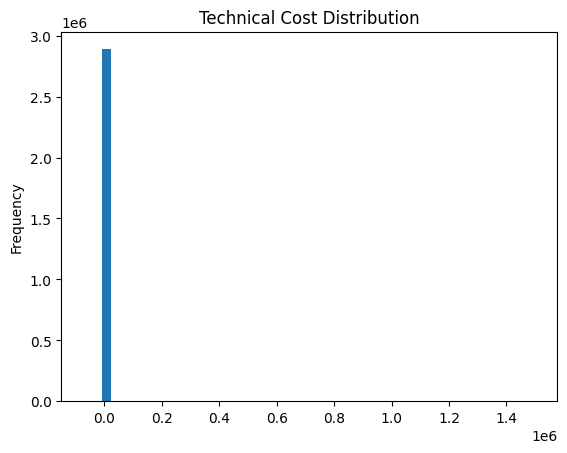

In [53]:
# Make inf or -inf values in technical cost 0
cb_df['technical_cost'] = cb_df['technical_cost'].replace([np.inf, -np.inf], 0)
cb_df["technical_cost"].plot(kind='hist', bins=50, title='Technical Cost Distribution')

In [54]:
cb_df.describe()

,primary_id,future_id,year,technical_cost,air_pollution
count,2.891793e+06,2.891793e+06,2.891793e+06,2.891793e+06,2.891777e+06
mean,4.385039e+07,4.995199e+04,2.036000e+03,2.205572e+02,8.862692e-01
std,2.887751e+04,2.887751e+04,8.366602e+00,1.079703e+04,7.758809e-01
min,4.380044e+07,0.000000e+00,2.022000e+03,-7.176681e+04,-2.167605e+00
25%,4.382537e+07,2.493200e+04,2.029000e+03,0.000000e+00,1.133397e-01
50%,4.385035e+07,4.990900e+04,2.036000e+03,0.000000e+00,7.870738e-01
75%,4.387545e+07,7.500900e+04,2.043000e+03,6.214129e+01,1.461118e+00
max,4.390044e+07,1.000000e+05,2.050000e+03,1.498830e+06,3.469385e+00


### LSU data

In [55]:
lsu_data = lsu_data[["primary_id",
               "time",
               "num_jobs",
               "earning_per_job"]]

lsu_data.head()

,primary_id,time,num_jobs,earning_per_job
0,43800487,6,0.000000e+00,<NA>
1,43800487,7,-1.818989e-12,45056.0
2,43800487,8,-4.547474e-13,114688.0
3,43800487,9,3.319656e-11,16159.561644
4,43800487,10,6.704874e-02,63858.822191


In [56]:
lsu_data= lsu_data.dropna()

In [57]:
lsu_data

,primary_id,time,num_jobs,earning_per_job
1,43800487,7,-1.818989e-12,45056.0
2,43800487,8,-4.547474e-13,114688.0
3,43800487,9,3.319656e-11,16159.561644
4,43800487,10,6.704874e-02,63858.822191
5,43800487,11,1.894780e+01,64608.010426
...,...,...,...,...
2923615,43900436,31,-1.133262e+05,10542.147264
2923616,43900436,32,-1.233538e+05,13909.320456
2923617,43900436,33,-1.238572e+05,13011.425596
2923618,43900436,34,-1.247343e+05,12189.975677


In [58]:
lsu_data['earning_per_job'].describe()

count     2.825033e+06
unique    2.533937e+06
top       1.724824e+04
freq      8.021000e+03
Name: earning_per_job, dtype: float64

## LHS Data

In [59]:
lhs_df_merged = lhs_df_merged.drop(columns=["design_id", "region"])
lhs_df_merged.head()

,future_id,46,47,48,49,50,51,52,53,54,...,1761,1762,1767,1768,1770,1778,1780,1792,1793,1801
100000,1,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,0.362738,0.958638,...,0.814377,0.142605,0.097383,0.613217,0.746290,0.004296,0.883196,0.430823,0.480203,0.542153
100001,2,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,0.486941,0.799062,...,0.945452,0.596037,0.761325,0.972692,0.957930,0.178317,0.059578,0.241647,0.867341,0.299005
100002,3,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,0.892889,0.603465,...,0.564013,0.843588,0.468507,0.615248,0.581179,0.297995,0.777503,0.309742,0.127848,0.024428
100003,4,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,0.084494,0.215486,...,0.521076,0.511969,0.006134,0.423707,0.044680,0.753944,0.089066,0.978027,0.193832,0.578752
100004,5,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,0.504623,0.661824,...,0.886965,0.814298,0.761830,0.453373,0.499034,0.864098,0.349058,0.324254,0.655437,0.735588


## Transform time series format into single-row format

### SISEPUEDE Emission data

In [61]:
# Keep only the primary_id, time_period, and emission_total columns
la_emission_total_df = decomposed_df[["primary_id", "time_period", "emission_total"]]
la_emission_total_df.head()

,primary_id,time_period,emission_total
0,43800497,7,192.501062
1,43800497,8,187.719262
2,43800497,9,189.224632
3,43800497,10,189.818129
4,43800497,11,190.762750


In [62]:
la_emission_total_df.tail()

,primary_id,time_period,emission_total
2899792,43900437,31,245.331001
2899793,43900437,32,247.375124
2899794,43900437,33,249.515249
2899795,43900437,34,251.749011
2899796,43900437,35,253.062113


### Emission data sum

In [63]:
# aggregate data by primary_id summing the emissions
la_emission_df_sum_agg = la_emission_total_df.groupby(["primary_id"]).sum().reset_index()

# Drop time period column
la_emission_df_sum_agg = la_emission_df_sum_agg.drop(columns=["time_period"])
la_emission_df_sum_agg.head()

,primary_id,emission_total
0,36800368,2517.359006
1,43800438,3072.011568
2,43800439,6450.512091
3,43800440,6683.626925
4,43800441,5766.140732


### Emission data mean

In [64]:
# Filter out rows with time_period < 31
la_filtered_emission_total_df = la_emission_total_df[la_emission_total_df["time_period"] >= 31]
la_filtered_emission_total_df = la_filtered_emission_total_df.reset_index(drop=True)
la_filtered_emission_total_df.head(7)

,primary_id,time_period,emission_total
0,43800497,31,160.134837
1,43800497,32,158.265185
2,43800497,33,156.532730
3,43800497,34,154.782053
4,43800497,35,152.836700
5,36800368,31,94.397525
6,36800368,32,100.346579


In [65]:
# aggregate data by primary_id by summing the emissions
la_emission_df_mean_agg = la_filtered_emission_total_df.groupby(["primary_id"]).mean().reset_index()

# Rename emission_total to emission_avg_last_five_years
la_emission_df_mean_agg.rename(columns={"emission_total": "emission_avg_last_five_years"}, inplace=True)
la_emission_df_mean_agg

,primary_id,time_period,emission_avg_last_five_years
0,36800368,33.0,106.593506
1,43800438,33.0,-6.239383
2,43800439,33.0,228.689851
3,43800440,33.0,251.347424
4,43800441,33.0,184.690777
...,...,...,...
99988,43900434,33.0,165.347876
99989,43900435,33.0,119.983349
99990,43900436,33.0,157.289714
99991,43900437,33.0,249.406499


In [66]:
# Drop year column as it is no longer needed
la_emission_df_mean_agg = la_emission_df_mean_agg.drop(columns=["time_period"])
la_emission_df_mean_agg.head()

,primary_id,emission_avg_last_five_years
0,36800368,106.593506
1,43800438,-6.239383
2,43800439,228.689851
3,43800440,251.347424
4,43800441,184.690777


### Combining emission agg into one df

In [67]:
print("la_emission_df_mean_agg shape:", la_emission_df_mean_agg.shape)
print("la_emission_df_sum_agg shape:", la_emission_df_sum_agg.shape)

la_emission_df_mean_agg shape: (99993, 2)
la_emission_df_sum_agg shape: (99993, 2)


In [68]:
la_emissions_df_merged = la_emission_df_mean_agg.merge(la_emission_df_sum_agg, on="primary_id", how="inner")
la_emissions_df_merged.head()

,primary_id,emission_avg_last_five_years,emission_total
0,36800368,106.593506,2517.359006
1,43800438,-6.239383,3072.011568
2,43800439,228.689851,6450.512091
3,43800440,251.347424,6683.626925
4,43800441,184.690777,5766.140732


In [69]:
print("la_emission_df_mean_agg shape:", la_emission_df_mean_agg.shape)

la_emission_df_mean_agg shape: (99993, 2)


### Production and Production Cost Data

In [70]:
industry_cost_vars = [
    c for c in ind_fuel_demand_by_sector.columns
    if c.startswith("energy_demand_capex_") or c.startswith("energy_demand_opex_")
]

In [71]:
industry_product_vars =  [
    c for c in ind_fuel_demand_by_sector.columns
    if c.startswith("energy_demand_")
    and "_capex_" not in c
    and "_opex_" not in c
]

In [72]:
ind_fuel_demand_by_sector[industry_cost_vars]

,energy_demand_capex_agriculture_and_livestock_biomass,energy_demand_opex_agriculture_and_livestock_biomass,energy_demand_capex_chemicals_biomass,energy_demand_opex_chemicals_biomass,energy_demand_capex_electronics_biomass,energy_demand_opex_electronics_biomass,energy_demand_capex_glass_biomass,energy_demand_opex_glass_biomass,energy_demand_capex_mining_biomass,energy_demand_opex_mining_biomass,...,energy_demand_capex_mining_oil,energy_demand_opex_mining_oil,energy_demand_capex_other_product_manufacturing_oil,energy_demand_opex_other_product_manufacturing_oil,energy_demand_capex_plastic_oil,energy_demand_opex_plastic_oil,energy_demand_capex_rubber_and_leather_oil,energy_demand_opex_rubber_and_leather_oil,energy_demand_capex_wood_oil,energy_demand_opex_wood_oil
0,5.724716e+06,2.146769e+06,317965.809889,119237.178709,92.322045,34.620767,2513.271361,942.476760,6314.756484,2368.033681,...,131459.510316,49297.316368,51815.362954,19430.761108,779719.332924,292394.749847,124912.074038,46842.027764,1.930689e+06,724008.208766
1,5.372716e+06,2.014769e+06,298057.573990,111771.590246,105.837249,39.688968,2426.435685,909.913382,6601.088476,2475.408179,...,120257.643686,45096.616382,54769.061601,20538.398100,787120.223762,295170.083911,128433.029088,48162.385908,1.880348e+06,705130.527630
2,5.769727e+06,2.163648e+06,268656.188746,100746.070780,114.317824,42.869184,2362.109450,885.791044,6889.094315,2583.410368,...,108794.637910,40797.989216,57862.308602,21698.365726,797321.423344,298995.533754,132475.520039,49678.320015,1.815382e+06,680768.281295
3,5.742602e+06,2.153476e+06,238421.547821,89408.080433,122.032109,45.762041,2367.976822,887.991308,7158.142341,2684.303378,...,97036.427955,36388.660483,61298.374448,22986.890418,791895.271016,296960.726631,134238.504762,50339.439286,1.749552e+06,656082.065166
4,5.715628e+06,2.143361e+06,211588.495763,79345.685911,129.265101,48.474413,2462.619596,923.482349,7405.033048,2776.887393,...,85072.375997,31902.140999,64926.828759,24347.560784,767252.343702,287719.628888,133015.459640,49880.797365,1.689624e+06,633609.070712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2899792,5.270317e+06,1.976369e+06,0.000000,0.000000,331.726961,124.397611,3938.069027,1476.775885,7921.482196,2970.555823,...,0.000000,0.000000,1585.821066,594.682900,0.000000,0.000000,0.000000,0.000000,5.810625e+05,217898.433304
2899793,5.270163e+06,1.976311e+06,0.000000,0.000000,338.739850,127.027444,4001.884470,1500.706676,7936.949834,2976.356188,...,0.000000,0.000000,1654.107542,620.290328,0.000000,0.000000,0.000000,0.000000,5.431225e+05,203670.919280
2899794,5.269451e+06,1.976044e+06,0.000000,0.000000,346.004571,129.751714,4067.574715,1525.340518,7955.922777,2983.471041,...,0.000000,0.000000,1724.522652,646.695994,0.000000,0.000000,0.000000,0.000000,5.065479e+05,189955.460852
2899795,5.267970e+06,1.975489e+06,0.000000,0.000000,353.532902,132.574838,4135.238675,1550.714503,7978.415264,2991.905724,...,0.000000,0.000000,1797.080724,673.905271,0.000000,0.000000,0.000000,0.000000,4.712956e+05,176735.841647


In [73]:
ind_fuel_demand_by_sector[industry_product_vars]

,energy_demand_enfu_subsector_total_pj_entc_fuel_biomass,energy_demand_agriculture_and_livestock_biomass,energy_demand_chemicals_biomass,energy_demand_electronics_biomass,energy_demand_glass_biomass,energy_demand_mining_biomass,energy_demand_other_product_manufacturing_biomass,energy_demand_paper_biomass,energy_demand_wood_biomass,energy_demand_enfu_subsector_total_pj_entc_fuel_coal,...,energy_demand_enfu_subsector_total_pj_entc_fuel_oil,energy_demand_agriculture_and_livestock_oil,energy_demand_chemicals_oil,energy_demand_electronics_oil,energy_demand_glass_oil,energy_demand_mining_oil,energy_demand_other_product_manufacturing_oil,energy_demand_plastic_oil,energy_demand_rubber_and_leather_oil,energy_demand_wood_oil
0,36.017886,5.148130,0.285941,0.000083,0.002260,0.005679,0.031915,67.212892,33.734585,63.003960,...,16.318166,25.639448,8.507847,0.005373,0.004605,0.118219,0.046597,0.701187,0.112331,1.736232
1,34.962556,4.831583,0.268038,0.000095,0.002182,0.005936,0.033135,65.984351,34.772445,37.816143,...,15.863293,24.062937,8.483177,0.005702,0.004902,0.108145,0.049253,0.707842,0.115497,1.690962
2,34.162696,5.188607,0.241597,0.000103,0.002124,0.006195,0.034061,64.830062,35.563369,68.398743,...,11.587141,25.841040,8.497075,0.005849,0.004732,0.097837,0.052034,0.717016,0.119133,1.632539
3,29.882798,5.164214,0.214408,0.000110,0.002129,0.006437,0.034908,63.317225,36.195323,51.019904,...,12.276208,25.719555,8.505441,0.006096,0.004524,0.087263,0.055124,0.712137,0.120718,1.573339
4,30.039144,5.139957,0.190278,0.000116,0.002215,0.006659,0.035757,61.510920,36.751135,51.099173,...,12.340437,25.598747,8.522053,0.006404,0.004484,0.076504,0.058387,0.689976,0.119618,1.519447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2899792,41.163630,4.739497,0.000000,0.000298,0.003541,0.007124,0.000529,8.381262,33.794197,164.356739,...,16.910507,23.604317,7.672926,0.013848,0.005644,0.000000,0.001426,0.000000,0.000000,0.522539
2899793,41.824010,4.739359,0.000000,0.000305,0.003599,0.007138,0.000542,5.631924,33.535571,165.385780,...,17.181799,23.603630,7.663277,0.014051,0.005691,0.000000,0.001488,0.000000,0.000000,0.488420
2899794,42.500976,4.738718,0.000000,0.000311,0.003658,0.007155,0.000556,2.833203,33.268374,166.361694,...,17.459905,23.600440,7.657763,0.014265,0.005741,0.000000,0.001551,0.000000,0.000000,0.455529
2899795,43.194269,4.737387,0.000000,0.000318,0.003719,0.007175,0.000569,0.000000,32.992462,167.284918,...,17.744718,23.593808,7.656356,0.014490,0.005794,0.000000,0.001616,0.000000,0.000000,0.423827


#### production cost

In [74]:
# Sum all the subsector emission columns across axis=1
la_production_cost_total_df = ind_fuel_demand_by_sector.copy()
la_production_cost_total_df["production_cost_total"] = la_production_cost_total_df[industry_cost_vars].sum(axis=1)

# Show only the inputs that went into the sum + the result
la_production_cost_total_df[industry_cost_vars + ["production_cost_total"]].head()


,energy_demand_capex_agriculture_and_livestock_biomass,energy_demand_opex_agriculture_and_livestock_biomass,energy_demand_capex_chemicals_biomass,energy_demand_opex_chemicals_biomass,energy_demand_capex_electronics_biomass,energy_demand_opex_electronics_biomass,energy_demand_capex_glass_biomass,energy_demand_opex_glass_biomass,energy_demand_capex_mining_biomass,energy_demand_opex_mining_biomass,...,energy_demand_opex_mining_oil,energy_demand_capex_other_product_manufacturing_oil,energy_demand_opex_other_product_manufacturing_oil,energy_demand_capex_plastic_oil,energy_demand_opex_plastic_oil,energy_demand_capex_rubber_and_leather_oil,energy_demand_opex_rubber_and_leather_oil,energy_demand_capex_wood_oil,energy_demand_opex_wood_oil,production_cost_total
0,5.724716e+06,2.146769e+06,317965.809889,119237.178709,92.322045,34.620767,2513.271361,942.476760,6314.756484,2368.033681,...,49297.316368,51815.362954,19430.761108,779719.332924,292394.749847,124912.074038,46842.027764,1.930689e+06,724008.208766,7.563706e+08
1,5.372716e+06,2.014769e+06,298057.573990,111771.590246,105.837249,39.688968,2426.435685,909.913382,6601.088476,2475.408179,...,45096.616382,54769.061601,20538.398100,787120.223762,295170.083911,128433.029088,48162.385908,1.880348e+06,705130.527630,7.482375e+08
2,5.769727e+06,2.163648e+06,268656.188746,100746.070780,114.317824,42.869184,2362.109450,885.791044,6889.094315,2583.410368,...,40797.989216,57862.308602,21698.365726,797321.423344,298995.533754,132475.520039,49678.320015,1.815382e+06,680768.281295,7.553865e+08
3,5.742602e+06,2.153476e+06,238421.547821,89408.080433,122.032109,45.762041,2367.976822,887.991308,7158.142341,2684.303378,...,36388.660483,61298.374448,22986.890418,791895.271016,296960.726631,134238.504762,50339.439286,1.749552e+06,656082.065166,7.541000e+08
4,5.715628e+06,2.143361e+06,211588.495763,79345.685911,129.265101,48.474413,2462.619596,923.482349,7405.033048,2776.887393,...,31902.140999,64926.828759,24347.560784,767252.343702,287719.628888,133015.459640,49880.797365,1.689624e+06,633609.070712,7.532905e+08


In [75]:
# Keep only the primary_id, time_period, and emission_total columns
la_production_cost_total_df = la_production_cost_total_df[["primary_id", "time_period", "production_cost_total"]]
la_production_cost_total_df.head()

,primary_id,time_period,production_cost_total
0,43800497,7,7.563706e+08
1,43800497,8,7.482375e+08
2,43800497,9,7.553865e+08
3,43800497,10,7.541000e+08
4,43800497,11,7.532905e+08


In [76]:
# aggregate data by primary_id summing the emissions
la_production_cost_df_mean_agg = la_production_cost_total_df.groupby(["primary_id"]).mean().reset_index()

# Drop time period column
la_production_cost_df_mean_agg = la_production_cost_df_mean_agg.drop(columns=["time_period"])
la_production_cost_df_mean_agg.head()

,primary_id,production_cost_total
0,36800368,1.077426e+09
1,43800438,1.056679e+09
2,43800439,1.110311e+09
3,43800440,1.032909e+09
4,43800441,1.135758e+09


In [77]:
la_production_cost_df_mean_agg.shape

(99993, 2)

#### production

In [78]:
# columns: base energy demand only (no capex/opex)
industry_product_vars = [
    c for c in ind_fuel_demand_by_sector.columns
    if c.startswith("energy_demand_") and "_capex_" not in c and "_opex_" not in c
]

la_production_total_df = ind_fuel_demand_by_sector.copy()
la_production_total_df["production_total"] = (
    la_production_total_df[industry_product_vars].sum(axis=1, min_count=1)
)

# show only what went into the sum + the result
la_production_total_df[industry_product_vars + ["production_total"]].head()


,energy_demand_enfu_subsector_total_pj_entc_fuel_biomass,energy_demand_agriculture_and_livestock_biomass,energy_demand_chemicals_biomass,energy_demand_electronics_biomass,energy_demand_glass_biomass,energy_demand_mining_biomass,energy_demand_other_product_manufacturing_biomass,energy_demand_paper_biomass,energy_demand_wood_biomass,energy_demand_enfu_subsector_total_pj_entc_fuel_coal,...,energy_demand_agriculture_and_livestock_oil,energy_demand_chemicals_oil,energy_demand_electronics_oil,energy_demand_glass_oil,energy_demand_mining_oil,energy_demand_other_product_manufacturing_oil,energy_demand_plastic_oil,energy_demand_rubber_and_leather_oil,energy_demand_wood_oil,production_total
0,36.017886,5.148130,0.285941,0.000083,0.002260,0.005679,0.031915,67.212892,33.734585,63.003960,...,25.639448,8.507847,0.005373,0.004605,0.118219,0.046597,0.701187,0.112331,1.736232,5924.758692
1,34.962556,4.831583,0.268038,0.000095,0.002182,0.005936,0.033135,65.984351,34.772445,37.816143,...,24.062937,8.483177,0.005702,0.004902,0.108145,0.049253,0.707842,0.115497,1.690962,5911.202400
2,34.162696,5.188607,0.241597,0.000103,0.002124,0.006195,0.034061,64.830062,35.563369,68.398743,...,25.841040,8.497075,0.005849,0.004732,0.097837,0.052034,0.717016,0.119133,1.632539,5914.897061
3,29.882798,5.164214,0.214408,0.000110,0.002129,0.006437,0.034908,63.317225,36.195323,51.019904,...,25.719555,8.505441,0.006096,0.004524,0.087263,0.055124,0.712137,0.120718,1.573339,5918.101023
4,30.039144,5.139957,0.190278,0.000116,0.002215,0.006659,0.035757,61.510920,36.751135,51.099173,...,25.598747,8.522053,0.006404,0.004484,0.076504,0.058387,0.689976,0.119618,1.519447,5920.629732


In [79]:
# Keep only the primary_id, time_period, and emission_total columns
la_production_total_df = la_production_total_df[["primary_id", "time_period", "production_total"]]
la_production_total_df.head()

,primary_id,time_period,production_total
0,43800497,7,5924.758692
1,43800497,8,5911.202400
2,43800497,9,5914.897061
3,43800497,10,5918.101023
4,43800497,11,5920.629732


In [80]:
# aggregate data by primary_id summing the emissions
la_production_df_mean_agg = la_production_total_df.groupby(["primary_id"]).mean().reset_index()

# Drop time period column
la_production_df_mean_agg = la_production_df_mean_agg.drop(columns=["time_period"])
la_production_df_mean_agg.head()

,primary_id,production_total
0,36800368,1551.124125
1,43800438,8849.651067
2,43800439,11255.133506
3,43800440,11988.891140
4,43800441,9659.985315


### CB data

In [81]:
# aggregate data by primary_id and region by summing the technical cost
cb_df_agg = cb_df.groupby(["primary_id", "future_id"]).mean().reset_index()
cb_df_agg

,primary_id,future_id,year,technical_cost,air_pollution
0,43800438,0,2036.0,0.000000,1.546379
1,43800439,1,2036.0,0.000000,1.099041
2,43800440,2,2036.0,0.000000,0.463927
3,43800441,3,2036.0,0.000000,0.697694
4,43800442,4,2036.0,0.000000,0.695005
...,...,...,...,...,...
99712,43900434,99996,2036.0,124.476953,1.178713
99713,43900435,99997,2036.0,90.618516,1.048632
99714,43900436,99998,2036.0,93.184114,0.930847
99715,43900437,99999,2036.0,99.775229,0.758739


In [82]:
# Drop year column as it is no longer needed
cb_df_agg = cb_df_agg.drop(columns=["year"], errors='ignore')
cb_df_agg.head()

,primary_id,future_id,technical_cost,air_pollution
0,43800438,0,0.0,1.546379
1,43800439,1,0.0,1.099041
2,43800440,2,0.0,0.463927
3,43800441,3,0.0,0.697694
4,43800442,4,0.0,0.695005


In [83]:
cb_df_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99717 entries, 0 to 99716
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   primary_id      99717 non-null  int64  
 1   future_id       99717 non-null  int64  
 2   technical_cost  99717 non-null  float64
 3   air_pollution   99717 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 3.0 MB


### LSU data

In [84]:
lsu_data

,primary_id,time,num_jobs,earning_per_job
1,43800487,7,-1.818989e-12,45056.0
2,43800487,8,-4.547474e-13,114688.0
3,43800487,9,3.319656e-11,16159.561644
4,43800487,10,6.704874e-02,63858.822191
5,43800487,11,1.894780e+01,64608.010426
...,...,...,...,...
2923615,43900436,31,-1.133262e+05,10542.147264
2923616,43900436,32,-1.233538e+05,13909.320456
2923617,43900436,33,-1.238572e+05,13011.425596
2923618,43900436,34,-1.247343e+05,12189.975677


In [85]:
# aggregate data by primary_id and region by summing the technical cost
lsu_data_agg = lsu_data.groupby(["primary_id"]).mean().reset_index()
lsu_data_agg

,primary_id,time,num_jobs,earning_per_job
0,43800438,21.0,-23353.709835,16755.06828
1,43800439,21.0,-45264.048312,-15326.861505
2,43800440,21.0,-40582.299332,-11855.185093
3,43800441,21.0,-34042.385712,-48447.698257
4,43800442,21.0,-48675.889667,5837.705269
...,...,...,...,...
97449,43900434,21.0,-31395.523586,-50680.950119
97450,43900435,21.0,-36372.935765,-40667.195361
97451,43900436,21.0,-46072.647150,-38437.679953
97452,43900437,21.0,-45355.448929,13019.26974


## Merge emissions and cb data with lhs samples

In [86]:
#attr_primary_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_PRIMARY_6004_filtered_metamodel_version.csv"))
attr_primary_df

,primary_id,design_id,strategy_id,future_id
1,43800438,4,6004,0
2,43800439,4,6004,1
3,43800440,4,6004,2
4,43800441,4,6004,3
5,43800442,4,6004,4
...,...,...,...,...
99997,43900434,4,6004,99996
99998,43900435,4,6004,99997
99999,43900436,4,6004,99998
100000,43900437,4,6004,99999


In [87]:
# Check for duplicates in primary_id
duplicates_primary = attr_primary_df[attr_primary_df.duplicated(subset=["primary_id"], keep=False)]
if not duplicates_primary.empty:
    print("Duplicated primary_id found:")
    print(duplicates_primary)
else:
    print("No duplicated primary_id found.")

# Check for duplicates in future_id
duplicates_future = attr_primary_df[attr_primary_df.duplicated(subset=["future_id"], keep=False)]
if not duplicates_future.empty:
    print("Duplicated future_id found:")
    print(duplicates_future)
else:
    print("No duplicated future_id found.")


No duplicated primary_id found.
No duplicated future_id found.


In [88]:
la_emission_df_w_future_id = la_emissions_df_merged.merge(attr_primary_df, on="primary_id", how="inner")

# Drop design_id and stratgy_id columns
la_emission_df_w_future_id = la_emission_df_w_future_id.drop(columns=["design_id", "strategy_id"])
la_emission_df_w_future_id

,primary_id,emission_avg_last_five_years,emission_total,future_id
0,43800438,-6.239383,3072.011568,0
1,43800439,228.689851,6450.512091,1
2,43800440,251.347424,6683.626925,2
3,43800441,184.690777,5766.140732,3
4,43800442,279.158564,7107.472492,4
...,...,...,...,...
99987,43900434,165.347876,5619.216459,99996
99988,43900435,119.983349,4858.510352,99997
99989,43900436,157.289714,5478.532808,99998
99990,43900437,249.406499,6610.448835,99999


In [89]:
la_ssp_out_df = la_emission_df_w_future_id.merge(la_production_df_mean_agg, on="primary_id", how="inner")
la_ssp_out_df = la_ssp_out_df.merge(la_production_cost_df_mean_agg, on="primary_id", how="inner")
la_ssp_out_df.head()

,primary_id,emission_avg_last_five_years,emission_total,future_id,production_total,production_cost_total
0,43800438,-6.239383,3072.011568,0,8849.651067,1.056679e+09
1,43800439,228.689851,6450.512091,1,11255.133506,1.110311e+09
2,43800440,251.347424,6683.626925,2,11988.891140,1.032909e+09
3,43800441,184.690777,5766.140732,3,9659.985315,1.135758e+09
4,43800442,279.158564,7107.472492,4,12251.510957,1.138632e+09


In [90]:
# Check that the shape is correct
print("la_ssp_out_df shape:", la_ssp_out_df.shape)
print("la_emission_df_w_future_id shape:", la_emission_df_w_future_id.shape)
print("la_production_df_sum_agg shape:", la_production_df_mean_agg.shape)
print("la_production_cost_df_sum_agg shape:", la_production_cost_df_mean_agg.shape)

la_ssp_out_df shape: (99992, 6)
la_emission_df_w_future_id shape: (99992, 4)
la_production_df_sum_agg shape: (99993, 2)
la_production_cost_df_sum_agg shape: (99993, 2)


In [91]:
la_ssp_out_df.isna().sum()

primary_id                         0
emission_avg_last_five_years       0
emission_total                     0
future_id                          0
production_total                2038
production_cost_total              0
dtype: int64

In [92]:
lhs_df_merged.head()

,future_id,46,47,48,49,50,51,52,53,54,...,1761,1762,1767,1768,1770,1778,1780,1792,1793,1801
100000,1,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,0.362738,0.958638,...,0.814377,0.142605,0.097383,0.613217,0.746290,0.004296,0.883196,0.430823,0.480203,0.542153
100001,2,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,0.486941,0.799062,...,0.945452,0.596037,0.761325,0.972692,0.957930,0.178317,0.059578,0.241647,0.867341,0.299005
100002,3,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,0.892889,0.603465,...,0.564013,0.843588,0.468507,0.615248,0.581179,0.297995,0.777503,0.309742,0.127848,0.024428
100003,4,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,0.084494,0.215486,...,0.521076,0.511969,0.006134,0.423707,0.044680,0.753944,0.089066,0.978027,0.193832,0.578752
100004,5,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,0.504623,0.661824,...,0.886965,0.814298,0.761830,0.453373,0.499034,0.864098,0.349058,0.324254,0.655437,0.735588


In [93]:
lhs_emissions_merged_df = pd.merge(lhs_df_merged, la_ssp_out_df, on="future_id", how="inner")
lhs_emissions_merged_df.head()

,future_id,46,47,48,49,50,51,52,53,54,...,1778,1780,1792,1793,1801,primary_id,emission_avg_last_five_years,emission_total,production_total,production_cost_total
0,1,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,0.362738,0.958638,...,0.004296,0.883196,0.430823,0.480203,0.542153,43800439,228.689851,6450.512091,11255.133506,1.110311e+09
1,2,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,0.486941,0.799062,...,0.178317,0.059578,0.241647,0.867341,0.299005,43800440,251.347424,6683.626925,11988.891140,1.032909e+09
2,3,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,0.892889,0.603465,...,0.297995,0.777503,0.309742,0.127848,0.024428,43800441,184.690777,5766.140732,9659.985315,1.135758e+09
3,4,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,0.084494,0.215486,...,0.753944,0.089066,0.978027,0.193832,0.578752,43800442,279.158564,7107.472492,12251.510957,1.138632e+09
4,5,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,0.504623,0.661824,...,0.864098,0.349058,0.324254,0.655437,0.735588,43800443,336.834484,7737.210438,12165.795353,1.234887e+09


In [94]:
lhs_emissions_merged_df.shape

(99991, 85)

In [95]:
cb_df_agg.head()

,primary_id,future_id,technical_cost,air_pollution
0,43800438,0,0.0,1.546379
1,43800439,1,0.0,1.099041
2,43800440,2,0.0,0.463927
3,43800441,3,0.0,0.697694
4,43800442,4,0.0,0.695005


In [96]:
complete_merged_df = pd.merge(lhs_emissions_merged_df, cb_df_agg, on=["future_id", "primary_id"], how="inner")

complete_merged_df.head()

,future_id,46,47,48,49,50,51,52,53,54,...,1792,1793,1801,primary_id,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution
0,1,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,0.362738,0.958638,...,0.430823,0.480203,0.542153,43800439,228.689851,6450.512091,11255.133506,1.110311e+09,0.0,1.099041
1,2,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,0.486941,0.799062,...,0.241647,0.867341,0.299005,43800440,251.347424,6683.626925,11988.891140,1.032909e+09,0.0,0.463927
2,3,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,0.892889,0.603465,...,0.309742,0.127848,0.024428,43800441,184.690777,5766.140732,9659.985315,1.135758e+09,0.0,0.697694
3,4,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,0.084494,0.215486,...,0.978027,0.193832,0.578752,43800442,279.158564,7107.472492,12251.510957,1.138632e+09,0.0,0.695005
4,5,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,0.504623,0.661824,...,0.324254,0.655437,0.735588,43800443,336.834484,7737.210438,12165.795353,1.234887e+09,0.0,0.927158


In [97]:
complete_merged_df

,future_id,46,47,48,49,50,51,52,53,54,...,1792,1793,1801,primary_id,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution
0,1,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,0.362738,0.958638,...,0.430823,0.480203,0.542153,43800439,228.689851,6450.512091,11255.133506,1.110311e+09,0.000000,1.099041
1,2,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,0.486941,0.799062,...,0.241647,0.867341,0.299005,43800440,251.347424,6683.626925,11988.891140,1.032909e+09,0.000000,0.463927
2,3,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,0.892889,0.603465,...,0.309742,0.127848,0.024428,43800441,184.690777,5766.140732,9659.985315,1.135758e+09,0.000000,0.697694
3,4,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,0.084494,0.215486,...,0.978027,0.193832,0.578752,43800442,279.158564,7107.472492,12251.510957,1.138632e+09,0.000000,0.695005
4,5,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,0.504623,0.661824,...,0.324254,0.655437,0.735588,43800443,336.834484,7737.210438,12165.795353,1.234887e+09,0.000000,0.927158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99711,99996,0.253400,0.788737,0.928313,0.537754,0.254415,0.929474,0.466627,0.955655,0.129971,...,0.010016,0.487650,0.766979,43900434,165.347876,5619.216459,9561.929502,1.238869e+09,124.476953,1.178713
99712,99997,0.441045,0.948774,0.455485,0.262397,0.303949,0.082500,0.727776,0.280893,0.818988,...,0.598896,0.995776,0.836911,43900435,119.983349,4858.510352,9964.858475,1.117176e+09,90.618516,1.048632
99713,99998,0.830664,0.555658,0.954550,0.664677,0.726851,0.573773,0.689922,0.476775,0.242713,...,0.612863,0.738723,0.586293,43900436,157.289714,5478.532808,11313.306125,1.243805e+09,93.184114,0.930847
99714,99999,0.755616,0.600732,0.247717,0.089843,0.260237,0.203080,0.124025,0.420096,0.711850,...,0.419098,0.842672,0.001281,43900437,249.406499,6610.448835,11326.717944,9.909464e+08,99.775229,0.758739


In [98]:
complete_merged_df = pd.merge(complete_merged_df, lsu_data_agg, on=[ "primary_id"], how="inner")
complete_merged_df

,future_id,46,47,48,49,50,51,52,53,54,...,primary_id,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,time,num_jobs,earning_per_job
0,1,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,0.362738,0.958638,...,43800439,228.689851,6450.512091,11255.133506,1.110311e+09,0.000000,1.099041,21.0,-45264.048312,-15326.861505
1,2,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,0.486941,0.799062,...,43800440,251.347424,6683.626925,11988.891140,1.032909e+09,0.000000,0.463927,21.0,-40582.299332,-11855.185093
2,3,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,0.892889,0.603465,...,43800441,184.690777,5766.140732,9659.985315,1.135758e+09,0.000000,0.697694,21.0,-34042.385712,-48447.698257
3,4,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,0.084494,0.215486,...,43800442,279.158564,7107.472492,12251.510957,1.138632e+09,0.000000,0.695005,21.0,-48675.889667,5837.705269
4,5,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,0.504623,0.661824,...,43800443,336.834484,7737.210438,12165.795353,1.234887e+09,0.000000,0.927158,21.0,-50583.469635,6625.620372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97448,99996,0.253400,0.788737,0.928313,0.537754,0.254415,0.929474,0.466627,0.955655,0.129971,...,43900434,165.347876,5619.216459,9561.929502,1.238869e+09,124.476953,1.178713,21.0,-31395.523586,-50680.950119
97449,99997,0.441045,0.948774,0.455485,0.262397,0.303949,0.082500,0.727776,0.280893,0.818988,...,43900435,119.983349,4858.510352,9964.858475,1.117176e+09,90.618516,1.048632,21.0,-36372.935765,-40667.195361
97450,99998,0.830664,0.555658,0.954550,0.664677,0.726851,0.573773,0.689922,0.476775,0.242713,...,43900436,157.289714,5478.532808,11313.306125,1.243805e+09,93.184114,0.930847,21.0,-46072.647150,-38437.679953
97451,99999,0.755616,0.600732,0.247717,0.089843,0.260237,0.203080,0.124025,0.420096,0.711850,...,43900437,249.406499,6610.448835,11326.717944,9.909464e+08,99.775229,0.758739,21.0,-45355.448929,13019.26974


In [99]:
print(complete_merged_df.shape)
print(complete_merged_df.future_id.nunique())

(97453, 90)
97453


In [100]:
complete_merged_df.isna().sum().sum()

np.int64(0)

In [101]:
# rearrange columns to have future_id and primary_id at the front
cols_order = ["future_id", "primary_id"] + [col for col in complete_merged_df.columns if col not in ["future_id", "primary_id"]]
complete_merged_df = complete_merged_df[cols_order]
complete_merged_df

,future_id,primary_id,46,47,48,49,50,51,52,53,...,1801,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,time,num_jobs,earning_per_job
0,1,43800439,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,0.362738,...,0.542153,228.689851,6450.512091,11255.133506,1.110311e+09,0.000000,1.099041,21.0,-45264.048312,-15326.861505
1,2,43800440,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,0.486941,...,0.299005,251.347424,6683.626925,11988.891140,1.032909e+09,0.000000,0.463927,21.0,-40582.299332,-11855.185093
2,3,43800441,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,0.892889,...,0.024428,184.690777,5766.140732,9659.985315,1.135758e+09,0.000000,0.697694,21.0,-34042.385712,-48447.698257
3,4,43800442,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,0.084494,...,0.578752,279.158564,7107.472492,12251.510957,1.138632e+09,0.000000,0.695005,21.0,-48675.889667,5837.705269
4,5,43800443,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,0.504623,...,0.735588,336.834484,7737.210438,12165.795353,1.234887e+09,0.000000,0.927158,21.0,-50583.469635,6625.620372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97448,99996,43900434,0.253400,0.788737,0.928313,0.537754,0.254415,0.929474,0.466627,0.955655,...,0.766979,165.347876,5619.216459,9561.929502,1.238869e+09,124.476953,1.178713,21.0,-31395.523586,-50680.950119
97449,99997,43900435,0.441045,0.948774,0.455485,0.262397,0.303949,0.082500,0.727776,0.280893,...,0.836911,119.983349,4858.510352,9964.858475,1.117176e+09,90.618516,1.048632,21.0,-36372.935765,-40667.195361
97450,99998,43900436,0.830664,0.555658,0.954550,0.664677,0.726851,0.573773,0.689922,0.476775,...,0.586293,157.289714,5478.532808,11313.306125,1.243805e+09,93.184114,0.930847,21.0,-46072.647150,-38437.679953
97451,99999,43900437,0.755616,0.600732,0.247717,0.089843,0.260237,0.203080,0.124025,0.420096,...,0.001281,249.406499,6610.448835,11326.717944,9.909464e+08,99.775229,0.758739,21.0,-45355.448929,13019.26974


In [102]:
complete_merged_df = complete_merged_df.drop(columns=["time"])

In [103]:
# Check for nans
complete_merged_df.isna().sum().sum()

np.int64(0)

## Filter out irrelevant lhs groups

In [104]:
var_traj_X_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "VARIABLE_TRAJECTORY_GROUPS_X.csv"))
var_traj_L_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "VARIABLE_TRAJECTORY_GROUPS_L.csv"))

In [105]:
var_traj_X_df.tail()

,variable,variable_trajectory_group
79,nemomod_entc_variable_cost_pp_solar_usd_per_mwh,57
80,nemomod_entc_variable_cost_pp_wind_usd_per_mwh,57
81,elasticity_trde_mtkm_to_gdp_freight,58
82,elasticity_trde_pkm_to_gdppc_private_and_public,59
83,elasticity_trde_pkm_to_gdppc_regional,59


In [106]:
var_traj_L_df.tail()

,transformation_code,variable,variable_field,variable_trajectory_group
456,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_paper,45
457,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_plastic,45
458,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_rubber_leather,45
459,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_textiles,45
460,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_wood,45


In [107]:
var_traj_groups_X = var_traj_X_df["variable_trajectory_group"].unique()
var_traj_groups_L = var_traj_L_df["variable_trajectory_group"].unique()
print("Variable trajectory groups X:", var_traj_groups_X)
print("Variable trajectory groups L:", var_traj_groups_L)

Variable trajectory groups X: [46 47 48 49 50 51 52 53 54 55 56 57 58 59]
Variable trajectory groups L: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]


In [108]:
# join the var_traj_groups
var_traj_groups_all = var_traj_groups_X.tolist() + var_traj_groups_L.tolist()
var_traj_groups_all = list(set(var_traj_groups_all))  # remove duplicates
print("All variable trajectory groups:", var_traj_groups_all)

All variable trajectory groups: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]


In [109]:
# Convert the variable_trajectory_group column to list of strings
relevant_lhs_cols = [str(col) for col in var_traj_groups_all]

In [110]:
df_cols = complete_merged_df.columns.tolist()

# Filter the relevant_lhs_cols to only include those that are in df_cols
relevant_lhs_cols = [col for col in relevant_lhs_cols if col in df_cols]

In [112]:
# filter complete_merged_df to keep only relevant columns
cols_to_keep = ["future_id", "primary_id"] + list(relevant_lhs_cols) + ["emission_avg_last_five_years", "emission_total", "production_total","production_cost_total","technical_cost", "air_pollution", "num_jobs","earning_per_job"]
merged_df_filtered = complete_merged_df[cols_to_keep]

In [113]:
print("Original merged DataFrame shape:", complete_merged_df.shape)
print("Filtered merged DataFrame shape:", merged_df_filtered.shape)

Original merged DataFrame shape: (97453, 89)
Filtered merged DataFrame shape: (97453, 69)


In [114]:
print("Filtered merged DataFrame fields:", merged_df_filtered.columns.tolist())
print("Relevant LHS columns:", relevant_lhs_cols)

Filtered merged DataFrame fields: ['future_id', 'primary_id', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', 'emission_avg_last_five_years', 'emission_total', 'production_total', 'production_cost_total', 'technical_cost', 'air_pollution', 'num_jobs', 'earning_per_job']
Relevant LHS columns: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59']


In [115]:
merged_df_filtered.head()

,future_id,primary_id,1,2,3,4,5,6,7,8,...,58,59,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
0,1,43800439,0.803011,0.496343,0.168613,0.203382,0.687640,0.651471,0.167822,0.318541,...,0.023251,0.519864,228.689851,6450.512091,11255.133506,1.110311e+09,0.0,1.099041,-45264.048312,-15326.861505
1,2,43800440,0.186768,0.161360,0.715659,0.520522,0.244624,0.432519,0.662078,0.659673,...,0.881897,0.307468,251.347424,6683.626925,11988.891140,1.032909e+09,0.0,0.463927,-40582.299332,-11855.185093
2,3,43800441,0.284609,0.129326,0.362011,0.434426,0.422840,0.683687,0.141129,0.492968,...,0.914823,0.078667,184.690777,5766.140732,9659.985315,1.135758e+09,0.0,0.697694,-34042.385712,-48447.698257
3,4,43800442,0.646471,0.046774,0.689050,0.070367,0.259922,0.168926,0.246849,0.185125,...,0.400283,0.013558,279.158564,7107.472492,12251.510957,1.138632e+09,0.0,0.695005,-48675.889667,5837.705269
4,5,43800443,0.833488,0.072018,0.845239,0.160506,0.398369,0.125452,0.115764,0.692139,...,0.453588,0.800351,336.834484,7737.210438,12165.795353,1.234887e+09,0.0,0.927158,-50583.469635,6625.620372


## Add variable names to lhs columns

In [116]:
var_traj_L_df.tail()

,transformation_code,variable,variable_field,variable_trajectory_group
456,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_paper,45
457,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_plastic,45
458,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_rubber_leather,45
459,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_textiles,45
460,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_wood,45


In [117]:
var_traj_L_df = var_traj_L_df[["variable_field", "variable_trajectory_group"]]
var_traj_L_df = var_traj_L_df.rename(columns={"variable_field": "variable"})
var_traj_L_df.head()

,variable,variable_trajectory_group
0,ef_agrc_anaerobicdom_rice_kg_ch4_ha,1
1,frac_agrc_agriculture_production_lost,2
2,frac_agrc_crop_residues_burned,3
3,frac_agrc_crop_residues_removed,3
4,frac_agrc_no_till_cereals,3


In [118]:
var_traj_X_df.tail()

,variable,variable_trajectory_group
79,nemomod_entc_variable_cost_pp_solar_usd_per_mwh,57
80,nemomod_entc_variable_cost_pp_wind_usd_per_mwh,57
81,elasticity_trde_mtkm_to_gdp_freight,58
82,elasticity_trde_pkm_to_gdppc_private_and_public,59
83,elasticity_trde_pkm_to_gdppc_regional,59


In [119]:
var_traj_all_df = pd.concat([var_traj_X_df, var_traj_L_df], ignore_index=True)
var_traj_all_df

,variable,variable_trajectory_group
0,exports_enfu_pj_fuel_ammonia,46
1,exports_enfu_pj_fuel_coal,46
2,exports_enfu_pj_fuel_crude,46
3,exports_enfu_pj_fuel_diesel,46
4,exports_enfu_pj_fuel_electricity,46
...,...,...
540,frac_waso_recycled_paper,45
541,frac_waso_recycled_plastic,45
542,frac_waso_recycled_rubber_leather,45
543,frac_waso_recycled_textiles,45


In [120]:
# drop duplicates if any
print("Before dropping duplicates, var_traj_all_df shape:", var_traj_all_df.shape)
var_traj_all_df = var_traj_all_df.drop_duplicates(subset=["variable", "variable_trajectory_group"])
print("After dropping duplicates, var_traj_all_df shape:", var_traj_all_df.shape)

Before dropping duplicates, var_traj_all_df shape: (545, 2)
After dropping duplicates, var_traj_all_df shape: (537, 2)


In [121]:
# check if there are any duplicated variable names
duplicated_vars = var_traj_all_df["variable"].duplicated().any()
if duplicated_vars:
    print("There are duplicated variable names in var_traj_all_df.")
else:
    print("No duplicated variable names in var_traj_all_df.")

No duplicated variable names in var_traj_all_df.


In [122]:
# Filter var_traj_all_df by sample_group in relevant_lhs_cols
relevant_lhs_cols = [int(col) for col in relevant_lhs_cols]
var_traj_all_df = var_traj_all_df[var_traj_all_df["variable_trajectory_group"].isin(relevant_lhs_cols)]
var_traj_all_df = var_traj_all_df.sort_values(by="variable_trajectory_group", ascending=True)
print("After filtering by relevant_lhs_cols, var_traj_all_df shape:", var_traj_all_df.shape)

After filtering by relevant_lhs_cols, var_traj_all_df shape: (537, 2)


In [123]:
def process_variable_prefix(df):
    result = []
    for group, group_df in df.groupby('variable_trajectory_group'):
        variables = group_df['variable'].tolist()
        if len(variables) == 1:
            prefix = variables[0]
        else:
            prefix = os.path.commonprefix(variables)
            # Clean trailing underscores
            prefix = prefix.rstrip('_')
            
        prefix = f"group_{group}_{prefix}"
        result.append({'variable_trajectory_group': group, 'variable_prefix': prefix})
    return pd.DataFrame(result)

prefix_df = process_variable_prefix(var_traj_all_df)
prefix_df

,variable_trajectory_group,variable_prefix
0,1,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha
1,2,group_2_frac_agrc_agriculture_production_lost
2,3,group_3_frac_agrc
3,4,group_4_qty_ccsq_mt_co2_captured_sequestered_b...
4,5,group_5_nemomod_entc_frac_min_share_production...
5,6,group_6_nemomod_en
6,7,group_7_
7,8,group_8_frac_fgtv_drained_and_waste_ch4_flared...
8,9,group_9_efficfactor_enfu_industrial_energy_fuel
9,10,group_10_scalar_inen_energy_demand


In [124]:
# Check for duplicates in variable_trajectory_group and variable_prefix
dups = prefix_df.duplicated(subset=["variable_trajectory_group", "variable_prefix"], keep=False)
if dups.any():
    print("Duplicated variable_trajectory_group and variable_prefix found:")
    print(prefix_df[dups])
else:
    print("No duplicated variable_trajectory_group and variable_prefix found.")

# Check for duplicates in variable_trajectory_group
dups_group = prefix_df.duplicated(subset=["variable_trajectory_group"], keep=False)
if dups_group.any():
    print("Duplicated variable_trajectory_group found:")
    print(prefix_df[dups_group])
else:
    print("No duplicated variable_trajectory_group found.")

# Check for duplicates in variable_prefix
dups_prefix = prefix_df.duplicated(subset=["variable_prefix"], keep=False)
if dups_prefix.any():
    print("Duplicated variable_prefix found:")
    print(prefix_df[dups_prefix])
else:
    print("No duplicated variable_prefix found.")

No duplicated variable_trajectory_group and variable_prefix found.
No duplicated variable_trajectory_group found.
No duplicated variable_prefix found.


In [125]:
# var_traj_all_df[var_traj_all_df["variable_trajectory_group"].isin([3, 13, 40])]

In [126]:
# prefix_df.loc[prefix_df["sample_group"] == 13, "variable_prefix"] = "group_13_frac_gnrl_eating_red_meats+"
# prefix_df.loc[prefix_df["sample_group"] == 40, "variable_prefix"] = "group_40_pij_lndu_grasslands+"

# prefix_df = prefix_df.sort_values(by="variable_prefix", ascending=True)
# prefix_df

In [127]:
# Let's use the prefix_df to rename the columns in merged_df_filtered
def rename_columns_with_prefix(merged_df, prefix_df):
    df = merged_df.copy()
    # Create a mapping from str(group) to prefix
    group_to_prefix = {str(row['variable_trajectory_group']): row['variable_prefix'] for _, row in prefix_df.iterrows()}
    # Only rename columns that match a group
    rename_dict = {col: group_to_prefix[col] for col in df.columns if col in group_to_prefix}
    df = df.rename(columns=rename_dict)
    return df

merged_df_filtered_w_prefix = rename_columns_with_prefix(merged_df_filtered, prefix_df)

In [128]:
merged_df_filtered_w_prefix

,future_id,primary_id,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,...,group_58_elasticity_trde_mtkm_to_gdp_freight,group_59_elasticity_trde_pkm_to_gdppc,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
0,1,43800439,0.803011,0.496343,0.168613,0.203382,0.687640,0.651471,0.167822,0.318541,...,0.023251,0.519864,228.689851,6450.512091,11255.133506,1.110311e+09,0.000000,1.099041,-45264.048312,-15326.861505
1,2,43800440,0.186768,0.161360,0.715659,0.520522,0.244624,0.432519,0.662078,0.659673,...,0.881897,0.307468,251.347424,6683.626925,11988.891140,1.032909e+09,0.000000,0.463927,-40582.299332,-11855.185093
2,3,43800441,0.284609,0.129326,0.362011,0.434426,0.422840,0.683687,0.141129,0.492968,...,0.914823,0.078667,184.690777,5766.140732,9659.985315,1.135758e+09,0.000000,0.697694,-34042.385712,-48447.698257
3,4,43800442,0.646471,0.046774,0.689050,0.070367,0.259922,0.168926,0.246849,0.185125,...,0.400283,0.013558,279.158564,7107.472492,12251.510957,1.138632e+09,0.000000,0.695005,-48675.889667,5837.705269
4,5,43800443,0.833488,0.072018,0.845239,0.160506,0.398369,0.125452,0.115764,0.692139,...,0.453588,0.800351,336.834484,7737.210438,12165.795353,1.234887e+09,0.000000,0.927158,-50583.469635,6625.620372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97448,99996,43900434,0.333180,0.508289,0.833189,0.937535,0.004101,0.358540,0.025339,0.027000,...,0.108868,0.412875,165.347876,5619.216459,9561.929502,1.238869e+09,124.476953,1.178713,-31395.523586,-50680.950119
97449,99997,43900435,0.309228,0.208707,0.408597,0.454657,0.515337,0.715198,0.040204,0.824678,...,0.359117,0.956358,119.983349,4858.510352,9964.858475,1.117176e+09,90.618516,1.048632,-36372.935765,-40667.195361
97450,99998,43900436,0.987476,0.690312,0.869490,0.290641,0.602146,0.973193,0.810146,0.642752,...,0.155292,0.868513,157.289714,5478.532808,11313.306125,1.243805e+09,93.184114,0.930847,-46072.647150,-38437.679953
97451,99999,43900437,0.686161,0.087933,0.423748,0.462424,0.230290,0.281264,0.165502,0.615662,...,0.019482,0.238883,249.406499,6610.448835,11326.717944,9.909464e+08,99.775229,0.758739,-45355.448929,13019.26974


In [129]:
print(merged_df_filtered.shape)
print(merged_df_filtered_w_prefix.shape)

(97453, 69)
(97453, 69)


In [130]:
# check for duplicated column names
duplicated_cols = merged_df_filtered_w_prefix.columns[merged_df_filtered_w_prefix.columns.duplicated()].tolist()
if duplicated_cols:
    print("Duplicated column names found:", duplicated_cols)
else:
    print("No duplicated column names found.")

No duplicated column names found.


## Finally we save the processed data as training data

In [131]:
size_mb = merged_df_filtered_w_prefix.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"DataFrame size: {size_mb:.2f} MB")

DataFrame size: 53.53 MB


In [132]:
#save the merged DataFrame to a Parquet file
merged_df_filtered_w_prefix.to_parquet(os.path.join(TRAINING_DIR_PATH, "training_data_v5.7.parquet"), index=False)